In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy

In [2]:
chickdf = pd.read_csv("chickwts.csv")

In [3]:
chickdf.shape

(71, 3)

In [4]:
chickdf.head()

,Unnamed: 0,weight,feed
0,1,179,horsebean
1,2,160,horsebean
2,3,136,horsebean
3,4,227,horsebean
4,5,217,horsebean


In [5]:
chickdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  71 non-null     int64
 1   weight      71 non-null     int64
 2   feed        71 non-null     str  
dtypes: int64(2), str(1)
memory usage: 2.3 KB


In [6]:
chickdf.describe()

,Unnamed: 0,weight
count,71.000000,71.000000
mean,36.000000,261.309859
std,20.639767,78.073700
min,1.000000,108.000000
25%,18.500000,204.500000
50%,36.000000,258.000000
75%,53.500000,323.500000
max,71.000000,423.000000


In [7]:
chickdf.groupby("feed")["weight"].mean().sort_values()

feed
horsebean    160.200000
linseed      218.750000
soybean      246.428571
meatmeal     276.909091
casein       323.583333
sunflower    328.916667
Name: weight, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

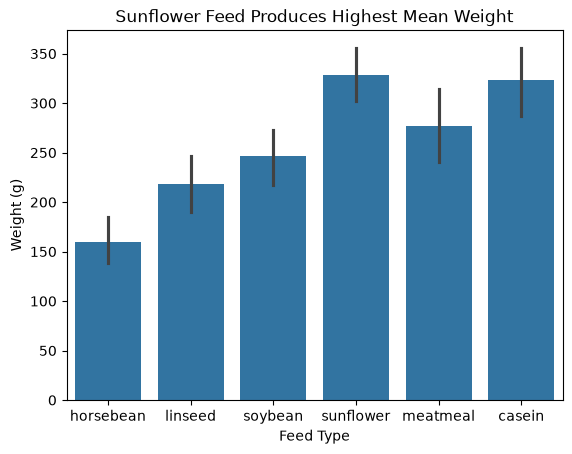

In [8]:
sns.barplot(data=chickdf, x="feed", y="weight")
plt.title("Sunflower Feed Produces Highest Mean Weight")
plt.xlabel("Feed Type")
plt.ylabel("Weight (g)")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

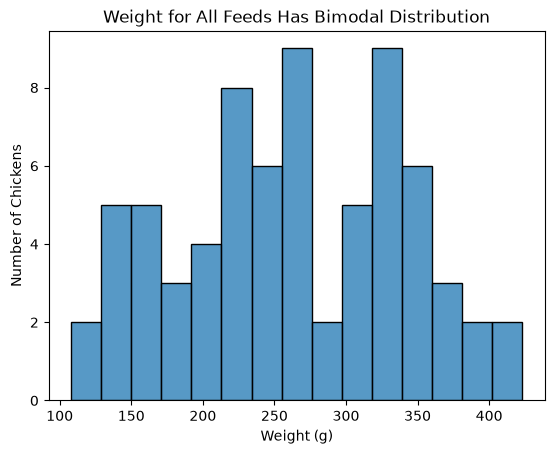

In [9]:
sns.histplot(data=chickdf, x="weight", bins=15)
plt.title("Weight for All Feeds Has Bimodal Distribution")
plt.xlabel("Weight (g)")
plt.ylabel("Number of Chickens")
plt.show

In [10]:
museumdf = pd.read_csv("museum_visitors.csv")

In [11]:
museumdf.shape

(59, 5)

In [12]:
museumdf.head()

,Date,Avila Adobe,Firehouse Museum,Chinese American Museum,America Tropical Interpretive Center
0,2014-01-01,24778,4486,1581,6602
1,2014-02-01,18976,4172,1785,5029
2,2014-03-01,25231,7082,3229,8129
3,2014-04-01,26989,6756,2129,2824
4,2014-05-01,36883,10858,3676,10694


In [13]:
museumdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 5 columns):
 #   Column                                Non-Null Count  Dtype
---  ------                                --------------  -----
 0   Date                                  59 non-null     str  
 1   Avila Adobe                           59 non-null     int64
 2   Firehouse Museum                      59 non-null     int64
 3   Chinese American Museum               59 non-null     int64
 4   America Tropical Interpretive Center  59 non-null     int64
dtypes: int64(4), str(1)
memory usage: 3.0 KB


In [14]:
museumdf.describe()

,Avila Adobe,Firehouse Museum,Chinese American Museum,America Tropical Interpretive Center
count,59.000000,59.000000,59.000000,59.000000
mean,24061.661017,6472.830508,2721.254237,7107.016949
std,5948.997414,7471.196609,1165.585196,2561.671286
min,14035.000000,3306.000000,1073.000000,2824.000000
25%,19469.500000,4412.500000,2134.000000,5424.500000
50%,23136.000000,5181.000000,2419.000000,6602.000000
75%,27502.000000,6239.500000,2942.500000,7943.000000
max,41242.000000,61192.000000,7702.000000,13490.000000


In [15]:
museumdf["Date"] = pd.to_datetime(museumdf["Date"], format="mixed")

In [16]:
museumdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 5 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   Date                                  59 non-null     datetime64[us]
 1   Avila Adobe                           59 non-null     int64         
 2   Firehouse Museum                      59 non-null     int64         
 3   Chinese American Museum               59 non-null     int64         
 4   America Tropical Interpretive Center  59 non-null     int64         
dtypes: datetime64[us](1), int64(4)
memory usage: 2.4 KB


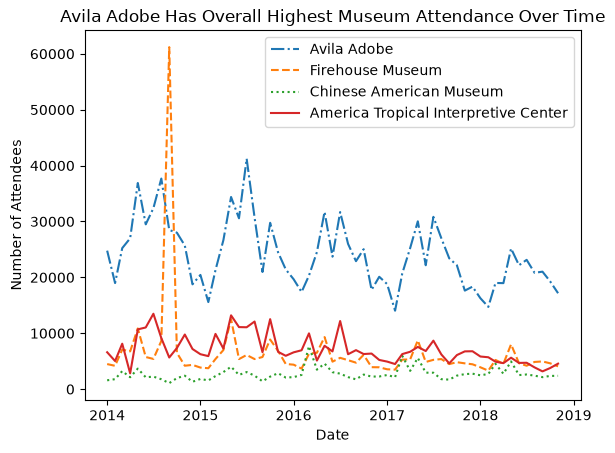

In [17]:
sns.lineplot(data=museumdf, x="Date", y="Avila Adobe", label="Avila Adobe", linestyle="-.")
sns.lineplot(data=museumdf, x="Date", y="Firehouse Museum", label="Firehouse Museum", linestyle="--")
sns.lineplot(data=museumdf, x="Date", y="Chinese American Museum", label="Chinese American Museum", linestyle=":")
sns.lineplot(data=museumdf, x="Date", y="America Tropical Interpretive Center", label="America Tropical Interpretive Center", linestyle="-")
plt.legend()
plt.title("Avila Adobe Has Overall Highest Museum Attendance Over Time")
plt.ylabel("Number of Attendees")
plt.show()

From this visualization of the data, we can see that Avila Adobe consistently has the highest number of attendees, except for a single month in 2014, in which Firehouse Museum had a gargantuan spike in attendance. 

<p>Because this spike (61192), visible as the maximum value of Firehouse Museum in the describe command earlier, is greater than that column's 75% value (6239.5) by a factor of ten, the most likely explanation is a typo or other error when recording values.

In [18]:
salesdf = pd.read_csv("sales_clean.csv")

In [19]:
salesdf["revenue"] = salesdf["price"] * salesdf["qty"]

<Axes: >

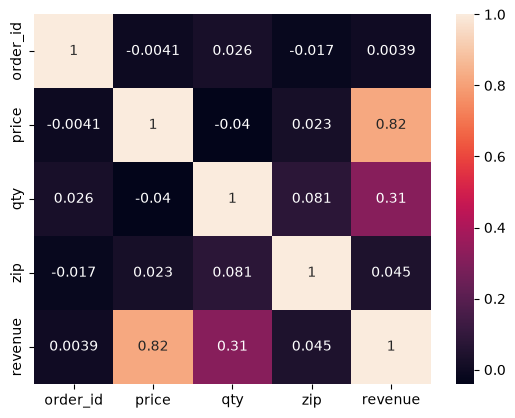

In [20]:
sns.heatmap(salesdf.corr(numeric_only=True), annot=True)

For the sales data that includes a "revenue" column, the strongest correlation is between the "revenue" and "price" columns.

In regards to the chick feed data, we will compare the weight of sunflower-fed chicks to that of horsebean-fed chicks.

<p>The null hypothesis (h0) is that there is no significant difference in weight between sunflower-fed chicks and horsebean-fed chicks.

In [21]:
from scipy.stats import ttest_ind
a = chickdf[chickdf["feed"] == "sunflower"]["weight"]
b = chickdf[chickdf["feed"] == "horsebean"]["weight"]
ttest_ind(a, b)

TtestResult(statistic=np.float64(8.848346742516636), pvalue=np.float64(2.374350767683718e-08), df=np.float64(20.0))

In comparing the weight yielded by these two feed types, the mean weight of sunflower-fed chicks was 328.9 grams, whereas the mean weight of horsebean-fed chicks was 160.2 grams. The effect size is a difference of 168.7 grams between the two mean weights. 

<p>The t-test yielded a t-value of approximately 8.85, with a p-value of approximately 2.37x10^-8. This t-value is sufficiently high and the p-value is extremely low, which indicates that differences between the two feeds is not merely a result of random chance. For this reason, we reject the null hypothesis. That said, one caution is that there may be other factors at this farm contributing to chick weight or their ability to digest the different feeds. Collecting data across multiple farms would help discern whether the results can be generalized.</p>

In the museum attendance chart, two honest design choices were the zero baseline and the use of varying line styles in addition to color differences. Encoding meaning solely in color would have rendered the chart less accessible and changing the zero baseline would have disingenuously exaggerated differences between the different museums.

I consulted the SciPy and seaborn User Guides throughout this lab:

<p>https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html
<p>https://seaborn.pydata.org/tutorial/properties.html</p>

Github Repo Url: https://github.com/journeyrahman/cs82a-portfolio